# 08 – Equilibrio Químico y Energía Libre de Gibbs

Si una reacción transcurre — y hasta qué punto — está gobernado por la **energía
libre de Gibbs**. A partir de la entalpía estandarizada y la entropía absoluta
proporcionadas por `pyglenn`, podemos construir la energía de Gibbs molar
estándar

$$G^\circ(T) = H^\circ(T) - T\,S^\circ(T),$$

la energía de Gibbs estándar de reacción $\Delta G^\circ(T)$ y la **constante de
equilibrio**

$$K(T) = \exp\!\left(-\frac{\Delta G^\circ(T)}{RT}\right).$$

Aplicamos esto a la reacción de **water-gas shift**, industrialmente importante,
y a la **disociación** a altas temperaturas, además de verificar la consistencia
con la ecuación de van't Hoff.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Energía de Gibbs y auxiliares de reacción

`gibbs` devuelve $G^\circ(T)$ para una especie; `reaction_props` devuelve
$\Delta H^\circ$, $\Delta S^\circ$, $\Delta G^\circ$ y $K$ para una reacción
dada como diccionarios `{especie: coeficiente}`.

In [3]:
def gibbs(calc, name, T):
    p = calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)
    return p["h_relative"] - T * p["s"]      # J/mol

def reaction_props(calc, reactants, products, T):
    def acc(mix, key, scale=1.0):
        tot = 0.0
        for name, nu in mix.items():
            p = calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)
            tot += nu * (p[key] if key != "g" else (p["h_relative"] - T * p["s"]))
        return tot
    dH = acc(products, "h_relative") - acc(reactants, "h_relative")
    dS = acc(products, "s") - acc(reactants, "s")
    dG = acc(products, "g") - acc(reactants, "g")
    K = np.exp(-dG / (R * T))
    return dH, dS, dG, K

## 2. La reacción de water-gas shift

$$\mathrm{CO} + \mathrm{H_2O} \rightleftharpoons \mathrm{CO_2} + \mathrm{H_2}.$$

Ligeramente exotérmica, por lo que, por el principio de Le Chatelier, se
favorece a bajas temperaturas y $K$ disminuye al subir la temperatura, cruzando
$K=1$ cerca de ~1100 K.

In [4]:
reac = {"CO": 1, "H2O": 1}
prod = {"CO2": 1, "H2": 1}

rows = []
with ThermochemicalCalculator() as calc:
    for T in [500, 700, 900, 1100, 1300]:
        dH, dS, dG, K = reaction_props(calc, reac, prod, T)
        rows.append({"T [K]": T, "dH [kJ/mol]": dH/1000, "dS [J/mol/K]": dS,
                     "dG [kJ/mol]": dG/1000, "K": K})
print(pd.DataFrame(rows).set_index("T [K]").to_string())

       dH [kJ/mol]  dS [J/mol/K]  dG [kJ/mol]       K
T [K]                                                
500        -39.815       -38.728      -20.451 136.906
700        -37.858       -35.449      -13.043   9.403
900        -35.778       -32.837       -6.226   2.298
1100       -33.773       -30.822        0.132   0.986
1300       -31.910       -29.264        6.134   0.567


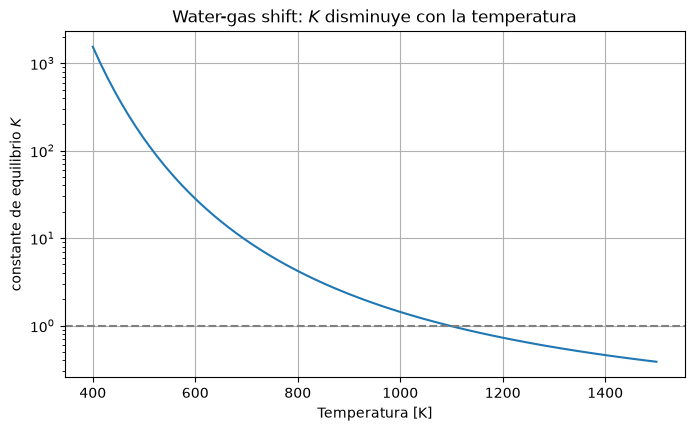

K = 1 (dG = 0) cerca de T = 1096 K


In [5]:
Tgrid = np.linspace(400, 1500, 80)
with ThermochemicalCalculator() as calc:
    K = np.array([reaction_props(calc, reac, prod, T)[3] for T in Tgrid])

fig, ax = plt.subplots()
ax.semilogy(Tgrid, K)
ax.axhline(1.0, color="0.5", ls="--")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("constante de equilibrio $K$")
ax.set_title("Water-gas shift: $K$ disminuye con la temperatura")
plt.show()

# temperatura donde K = 1 (dG = 0), por cambio de signo
sign = np.sign(np.log(K))
idx = np.where(np.diff(sign) != 0)[0]
if len(idx):
    T_cross = np.interp(0.0, [np.log(K[idx[0]]), np.log(K[idx[0]+1])],
                        [Tgrid[idx[0]], Tgrid[idx[0]+1]])
    print(f"K = 1 (dG = 0) cerca de T = {T_cross:.0f} K")

## 3. Verificación de van't Hoff

La ecuación de van't Hoff relaciona la pendiente de $\ln K$ frente a $1/T$ con
la entalpía de reacción:

$$\frac{d\ln K}{d(1/T)} = -\frac{\Delta H^\circ}{R}.$$

Trazar $\ln K$ vs. $1/T$ da una línea casi recta; su pendiente local recupera
$\Delta H^\circ$ calculado directamente — una buena comprobación de consistencia
interna.

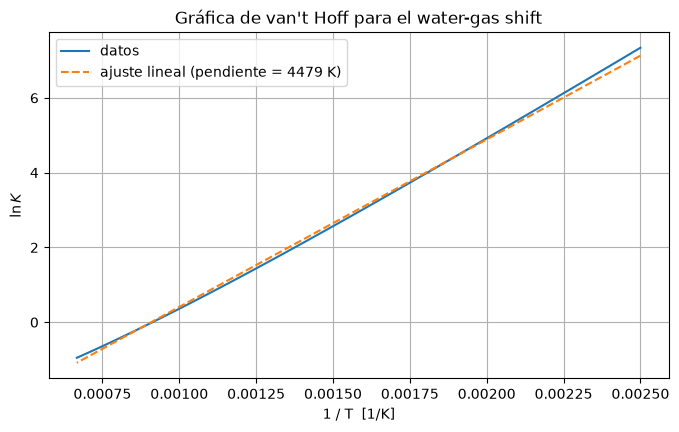

dH de la pendiente local de van't Hoff :  -35.20 kJ/mol
dH de la regresión lineal              :  -37.24 kJ/mol
dH calculado directamente               :  -35.20 kJ/mol


In [6]:
invT = 1.0 / Tgrid
lnK = np.log(K)
i = len(Tgrid) // 2
slope = (lnK[i+1] - lnK[i-1]) / (invT[i+1] - invT[i-1])
dH_vanthoff = -slope * R
with ThermochemicalCalculator() as calc:
    dH_direct = reaction_props(calc, reac, prod, Tgrid[i])[0]

# Regresión lineal para visualizar la pendiente de van't Hoff
fit = np.polyfit(invT, lnK, 1)
lnK_fit = np.polyval(fit, invT)
dH_fit = -fit[0] * R  # pendiente = -dH/R

fig, ax = plt.subplots()
ax.plot(invT, lnK, label="datos")
ax.plot(invT, lnK_fit, "--", color="C1",
        label=f"ajuste lineal (pendiente = {fit[0]:.0f} K)")
ax.set_xlabel("1 / T  [1/K]")
ax.set_ylabel(r"$\ln K$")
ax.set_title("Gráfica de van't Hoff para el water-gas shift")
ax.legend()
plt.show()
print(f"dH de la pendiente local de van't Hoff : {dH_vanthoff/1000:7.2f} kJ/mol")
print(f"dH de la regresión lineal              : {dH_fit/1000:7.2f} kJ/mol")
print(f"dH calculado directamente               : {dH_direct/1000:7.2f} kJ/mol")

## 4. Disociación a altas temperaturas

Las moléculas diatómicas se dividen en átomos a temperaturas extremas — un
proceso fuertemente endotérmico ($\Delta H^\circ \approx +945$ kJ/mol para N₂,
$+498$ kJ/mol para O₂). Sus constantes de equilibrio son astronómicamente
pequeñas a temperaturas moderadas y solo se vuelven apreciables en el rango de
miles de kelvin, razón por la cual las temperaturas de llama de combustión
completa del cuaderno 06 están sobreestimadas.

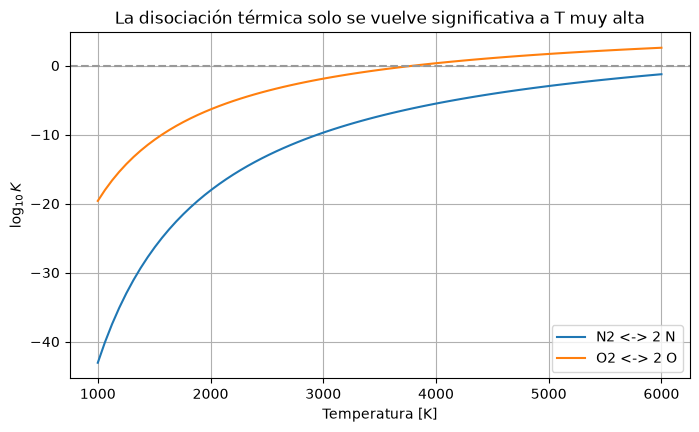

Entalpía de disociación del enlace N2 -> 2N a 298 K: 945 kJ/mol


In [7]:
dissociations = {
    "N2 <-> 2 N": ({"N2": 1}, {"N": 2}),
    "O2 <-> 2 O": ({"O2": 1}, {"O": 2}),
}
Tgrid = np.linspace(1000, 6000, 80)
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label, (r, p) in dissociations.items():
        logK = [np.log10(reaction_props(calc, r, p, T)[3]) for T in Tgrid]
        ax.plot(Tgrid, logK, label=label)
    dH_N2 = reaction_props(calc, {"N2": 1}, {"N": 2}, 298.15)[0]
ax.axhline(0.0, color="0.6", ls="--")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel(r"$\log_{10} K$")
ax.set_title("La disociación térmica solo se vuelve significativa a T muy alta")
ax.legend()
plt.show()
print(f"Entalpía de disociación del enlace N2 -> 2N a 298 K: {dH_N2/1000:.0f} kJ/mol")

## 5. Control entálpico vs. entrópico

$\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$ hace explícita la
competencia: el término entálpico domina a bajas $T$, el término entrópico
(ponderado por $T$) a altas $T$. La disociación ($\Delta S^\circ > 0$, más moles
de gas) está impulsada por la entropía y, por tanto, se activa a alta
temperatura, mientras que la reacción exotérmica de water-gas shift está
favorecida entálpicamente a baja temperatura. Visualizamos las dos contribuciones
para la disociación del N₂.

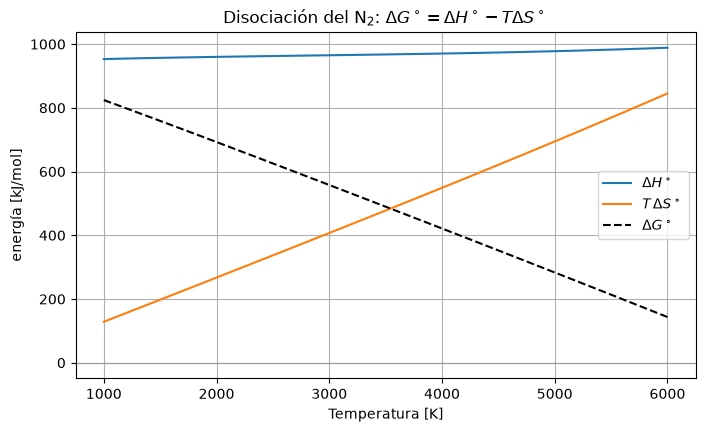

In [8]:
Tgrid = np.linspace(1000, 6000, 80)
with ThermochemicalCalculator() as calc:
    dH = np.array([reaction_props(calc, {"N2": 1}, {"N": 2}, T)[0] for T in Tgrid]) / 1000
    TdS = np.array([T * reaction_props(calc, {"N2": 1}, {"N": 2}, T)[1] for T in Tgrid]) / 1000
    dG = np.array([reaction_props(calc, {"N2": 1}, {"N": 2}, T)[2] for T in Tgrid]) / 1000

fig, ax = plt.subplots()
ax.plot(Tgrid, dH, label=r"$\Delta H^\circ$")
ax.plot(Tgrid, TdS, label=r"$T\,\Delta S^\circ$")
ax.plot(Tgrid, dG, "k--", label=r"$\Delta G^\circ$")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("energía [kJ/mol]")
ax.set_title(r"Disociación del N$_2$: $\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$")
ax.legend()
plt.show()

## Resumen

- $G^\circ = H^\circ - T S^\circ$ de `pyglenn` proporciona $\Delta G^\circ(T)$ y,
  por tanto, $K(T)$ para cualquier reacción.
- El $K$ del water-gas shift cae por debajo de 1 cerca de 1100 K; la pendiente
  de van't Hoff reproduce la entalpía de reacción.
- La disociación está impulsada por la entropía y solo importa a temperaturas muy
  altas, explicando la advertencia sobre la temperatura de llama del cuaderno 06.

**A continuación:** el cuaderno 09 aplica propiedades dependientes de la
temperatura a un ciclo de turbina de gas.